----

# Información de los datos recopilados
### Librerias
* <a href='https://pandas.pydata.org/pandas-docs/stable/reference/index.html'>pandas (Panel Data)</a>, incluye funciones integradas para limpiar, transformar, manipular, visualizar y analizar datos.
* <a href='https://docs.python.org/es/3/library/math.html'>math</a>, proporciona acceso a las funciones matemáticas definidas en el estándar de C.
* <a href='https://matplotlib.org/'>matplotlib</a>, Matplotlib es una biblioteca completa para crear visualizaciones estáticas, animadas e interactivas en Python.
* <a href='https://plotly.com/python/'>plotly</a>, La biblioteca gráfica Python de Plotly crea gráficos interactivos con calidad de publicación. Ejemplos de cómo crear gráficos de líneas, diagramas de dispersión, gráficos de área, gráficos de barras, barras de error, diagramas de caja, histogramas, mapas de calor, subgráficos, ejes múltiples, gráficos polares y gráficos de burbujas.
* <a href='https://numpy.org/'>numpy</a>, NumPy es el paquete fundamental para la computación científica en Python. Es una biblioteca de Python que proporciona un objeto de matriz multidimensional, varios objetos derivados (como matrices y matrices enmascaradas) y una variedad de rutinas para operaciones rápidas en matrices

In [1]:
#Importación de librerias
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns

#Imprimir los graficos en el notebook
%matplotlib inline

In [2]:
#Variables generales
ruta_model = "../Model/"
ruta_df = "../Datasets/"

semilla = 111

In [3]:
#Carga de datos
df = pd.read_csv('{}data.csv'.format(ruta_df))

In [4]:
#Vista aleatoria de los datos
df.sample(10)

,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
41157,15CCB7CF696B2716B130932613C98724,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.83,9.76,20.04,12.19,17.91,18.07,18.64,18.00,16.03,14.40
5883,A99CCDCD0B2065C4E5D910CEBD32FB4C,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3863,5D4224F33D6C29439767D3B944C6DD2C,0,5.00,3.69,3.40,2.82,4.25,3.70,3.45,3.97,...,4.25,5.63,5.28,4.03,6.40,5.09,8.12,6.56,6.86,6.06
24311,F159B84516637598DA6D4B6E436A7A92,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
16358,230FC02D99BD78328298124F4DD17DBD,0,4.07,1.65,2.41,3.68,2.74,5.69,0.00,2.75,...,1.05,2.91,1.52,5.47,4.16,2.32,1.50,1.42,4.83,5.14
11612,F421AFF0109502A49FC8E675DDD0C6AD,0,0.00,0.00,0.56,0.00,0.00,0.00,0.00,0.00,...,1.15,0.96,1.18,1.37,1.32,1.24,1.24,1.19,1.41,1.32
970,AA6FC8B3D0C974A2B592DE6C2EF9502F,1,0.29,0.26,0.29,0.34,0.32,0.22,0.26,0.26,...,7.36,11.62,9.95,9.38,8.71,7.70,10.06,10.43,7.17,8.06
14123,EF8887019A91962FB2BDC55A1872494F,0,6.28,15.68,23.37,13.78,10.91,10.35,12.49,0.00,...,NaN,2.87,5.28,3.90,4.10,4.10,3.74,4.36,3.75,6.00
39146,7089C8D2705D2BAA5A47D2534902E9EB,0,16.61,14.94,13.08,15.59,11.44,21.46,12.40,13.67,...,1.17,0.00,0.17,0.00,5.66,6.37,3.41,4.93,4.93,2.65
38044,BEAA364B7F73D77CE8E1541E758D814C,0,4.14,8.16,10.06,11.34,0.00,7.98,9.91,11.03,...,0.67,0.71,1.85,0.64,1.51,0.79,0.63,0.68,0.62,0.66


In [5]:
'''
Para visualizar el comportamiento por los periodos se debe hacer un pivot de la tabla;
este paso se peude realizar sin la necesidad de reemplazar o eliminar los NaN.
'''

#Guardamos el nombre las columnas
col = df.iloc[:, 2:].columns

#Grafico 1. Suma de consumos - Lineas
px.line(data_frame = df.pivot_table(
    columns="FLAG",
    values=col,
    aggfunc="sum"
), title='Suma de Consumos')

In [6]:
#Distribución de los datos en base al FLAG
Flag_0, Flag_1 = df.FLAG.value_counts()
Filas, Columnas = df.shape
print(f"""
Duración de los datos recopilados: {df.columns[2]} - {df.columns[Columnas-1]}

Dimensión: {Columnas-2}

Consumidores Honestos: {Flag_0}\nConsumidores Fraudulentos: {Flag_1}

Consumidores Totales: {Filas}
      """)


Duración de los datos recopilados: 2014/1/1 - 2016/9/9

Dimensión: 1034

Consumidores Honestos: 38757
Consumidores Fraudulentos: 3615

Consumidores Totales: 42372
      


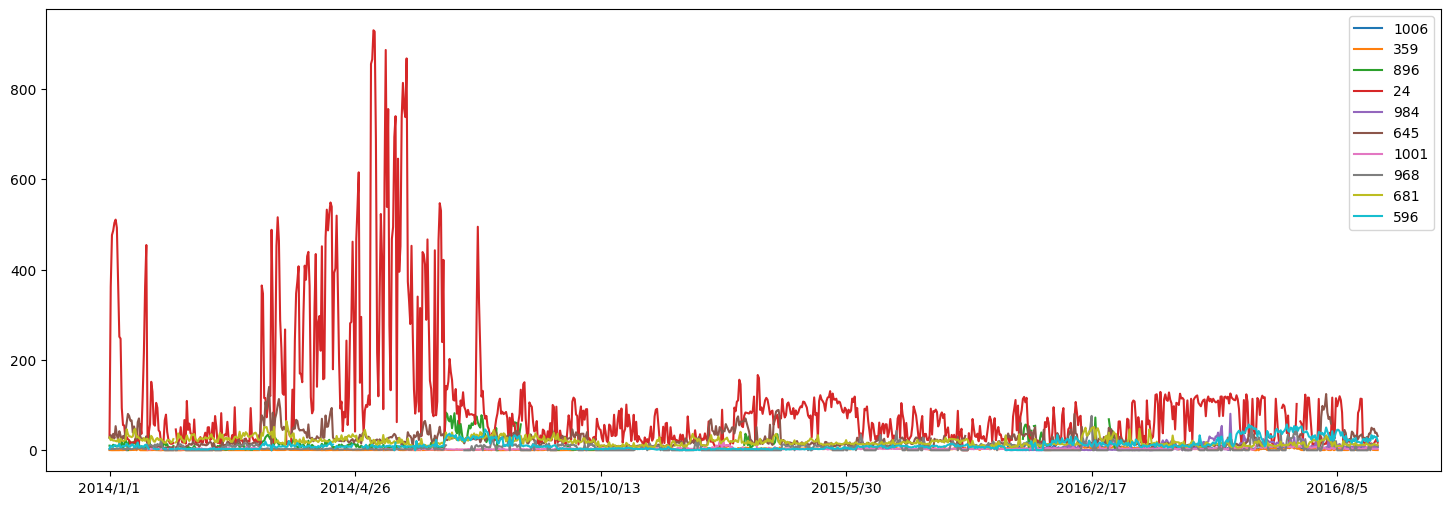

In [7]:
fig, ax = plt.subplots()
df.iloc[:, 2:].T.iloc[:,np.random.randint(0, len(df.columns), size= 10)].plot(ax = ax)
fig.set_size_inches(18, 6)
plt.show()

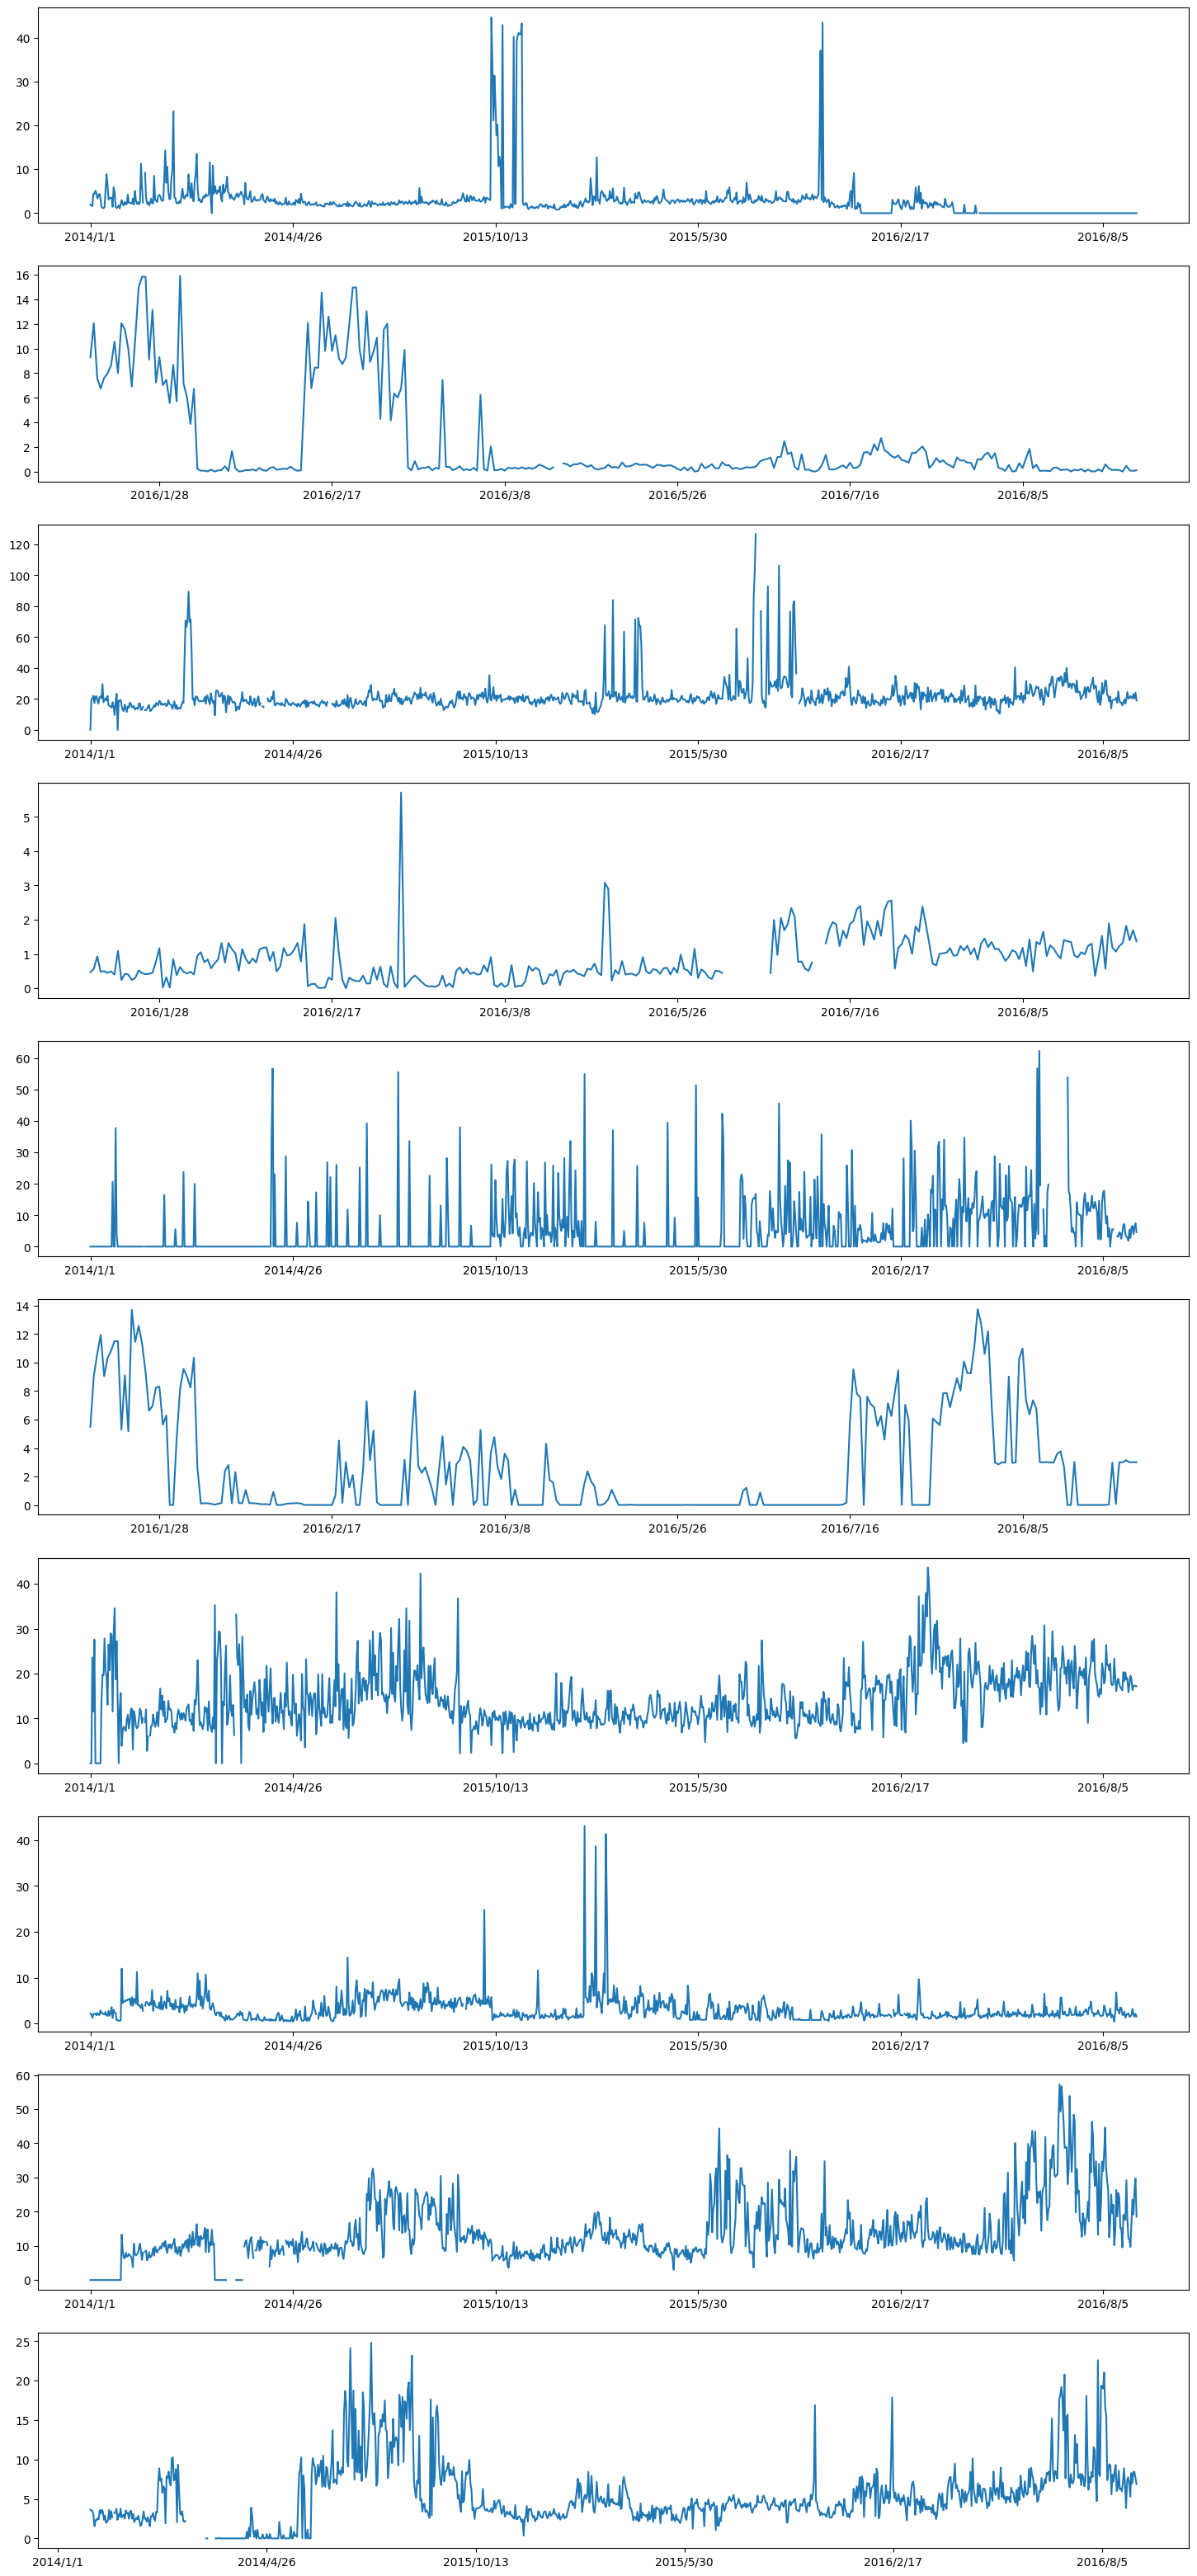

In [8]:
# Lista de índices que deseas plotear
indices = [580, 921, 471, 826, 879, 962, 489, 594, 849, 81]

# Crear la figura y los ejes
fig, ax = plt.subplots(nrows=len(indices), ncols=1, figsize=(18, 40))

# Plotear cada índice en su respectivo eje
for i, index in enumerate(indices):
    df.iloc[:, 2:].T.iloc[:, index].plot(ax=ax[i])

# Mostrar el gráfico
plt.show()

-----
# 1. Preprocesamiento de datos

---
#### 1.1. Completar NaN

In [9]:
'''
Creamos copias de los datasets
Significa primero construir un nuevo objeto de colección 
y luego rellenarlo recursivamente con copias de los objetos secundarios 
que se encuentran en el original
'''
df_interpolation_method = df.copy()
df_LinearRegression = df.copy()

#### Interpolation Method

\begin{split}
& \{\left({ \frac{ x_ {i+ 1} + x_ {i-1}}{2} }\right) _....if x_ i \in  NaN, x_ {i- 1} and x_ {i+ 1}\notin\\
f(x_ {i})=& \{{ 0 } _.... if x_ i \in  NaN, x_ {i- 1} or x_ {i+ 1} \in NaN\\
& \{{x_ i} _.... if x_ \notin NaN
\end{split}

In [10]:
%%time
"""
la 2da forma, es aplicando la vectorización.
"""
for i in range(2, len(df_interpolation_method.columns)):
    if i in (2, 1035) :
        df_interpolation_method.fillna(
            {df_interpolation_method.columns[i]: 0}
            , inplace= True
            , axis= 0
        )
    else :
        df_interpolation_method.fillna(
            {df_interpolation_method.columns[i]: 
             ((df_interpolation_method[df_interpolation_method.columns[i - 1]] + df_interpolation_method[df_interpolation_method.columns[i + 1]])/2).fillna(0)}
            , inplace= True
            , axis= 0
        )
    

Wall time: 1.31 s


In [11]:
%%time
#Guardado de resultado
df_interpolation_method.to_csv('{}data_Interpolation_Method.csv'.format(ruta_df), index=False)

Wall time: 29.4 s


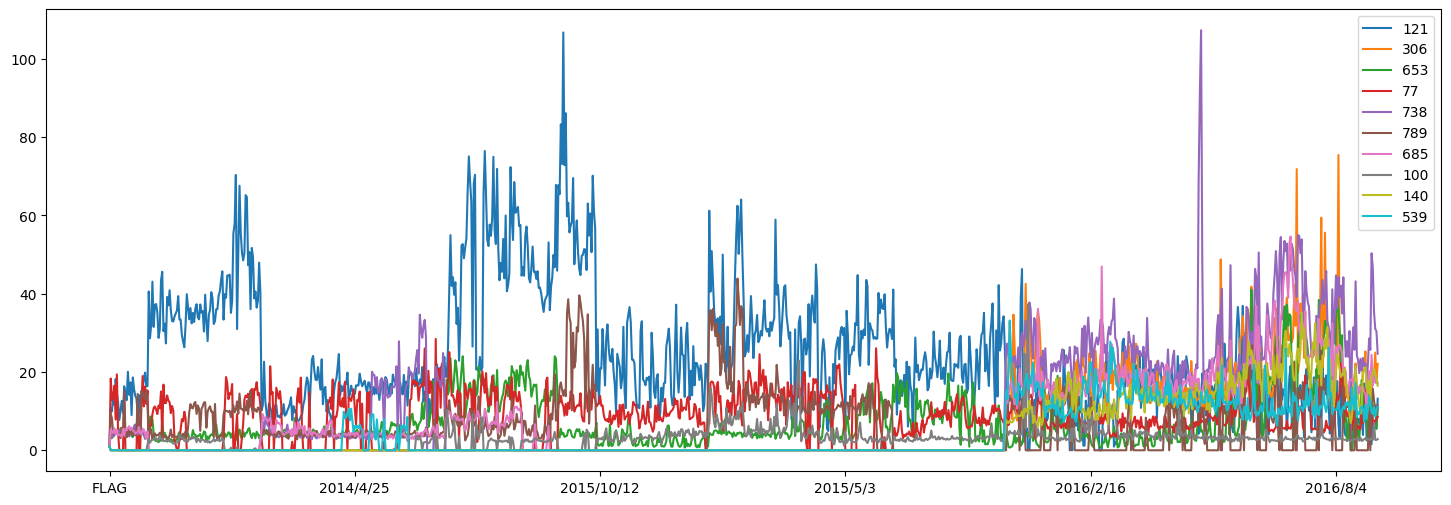

In [12]:
#Vista aleatoria del comprotamiento de los consumos
#plt.figure(figsize=(128,6))
fig, ax = plt.subplots()
df_interpolation_method.iloc[:, 1:].T.iloc[:,np.random.randint(0, len(df_interpolation_method.columns), size= 10)].plot(ax = ax)
fig.set_size_inches(18, 6)
plt.show()



#### Regresión Lineal

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression as LR

In [14]:
_df = df_LinearRegression.loc[:,'2014/1/1':]

In [15]:
imputer = IterativeImputer(estimator=LR()
                           , missing_values= np.nan
                           , max_iter= 2
                           , verbose= 3
                           , n_nearest_features = 12
                           , min_value = 0
                           , imputation_order= 'ascending'
                           , random_state= semilla) 

In [16]:
%%time
imputer_lr = imputer.fit_transform(_df)
_df_ = pd.DataFrame(imputer_lr)

[IterativeImputer] Completing matrix with shape (42372, 1034)
[IterativeImputer] Ending imputation round 1/2, elapsed time 22.53
[IterativeImputer] Change: 1129707.362643037, scaled tolerance: 800.0033199999999 
[IterativeImputer] Ending imputation round 2/2, elapsed time 43.19
[IterativeImputer] Change: 1242272.6042461996, scaled tolerance: 800.0033199999999 


C:\Users\pedro\AppData\Roaming\Python\Python310\site-packages\sklearn\impute\_iterative.py:713: ConvergenceWarning:

[IterativeImputer] Early stopping criterion not reached.



Wall time: 47.2 s


In [17]:
%%time
df_lr = pd.concat([df_LinearRegression[['CONS_NO','FLAG']] ,_df_], axis=1)
df_lr.to_csv('{}data_Linear_Regression.csv'.format(ruta_df), index=False)

Wall time: 41.2 s


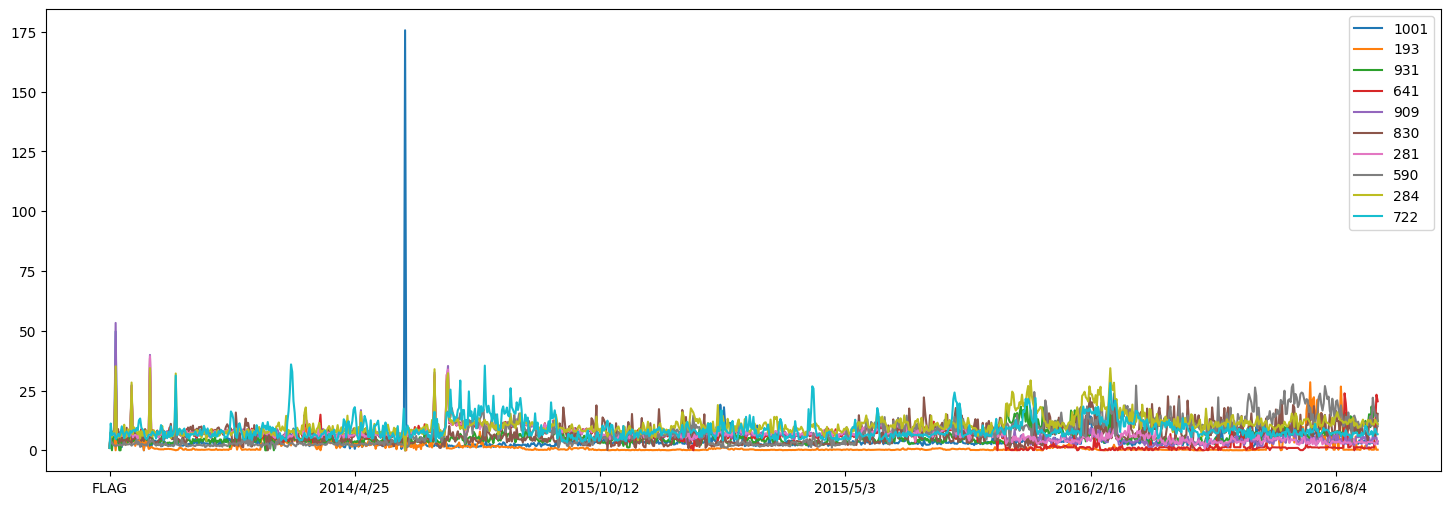

In [18]:
#Vista aleatoria del comprotamiento de los consumos
df_lr.columns= df_interpolation_method.columns
fig, ax = plt.subplots()
df_lr.iloc[:, 1:].T.iloc[:,np.random.randint(0, len(df_interpolation_method.columns), size= 10)].plot(ax = ax)
fig.set_size_inches(18, 6)
plt.show()

----

#### 1.2. suavización de los valores usando Three sigma rule of thumb

* **usando el dataset Interpolation Method**

In [19]:
df = pd.read_csv('{}data_Interpolation_Method.csv'.format(ruta_df))
df.head(10)

,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
0,0387DD8A07E07FDA6271170F86AD9151,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,10.12,9.96,16.92,7.60,27.22,18.05,26.47,18.75,17.84,14.92
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,6.50,9.99,11.78,18.59,26.80,18.57,14.59,12.82,19.37,15.92
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.90,3.42,3.81,4.58,3.56,4.25,3.86,3.53,...,17.77,10.37,15.32,13.51,12.23,14.68,16.35,18.14,18.41,17.31
5,6BCFD78138BC72A9BA1BFB0B79382192,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,2.82,5.52,3.12,3.13,4.20,3.23,3.85,2.78,3.55,2.54
6,34C1954AA3703C4F8BD8EAEA7C4B7B83,1,0.11,0.53,0.45,0.51,1.32,0.71,0.12,0.52,...,4.33,2.46,1.23,3.19,1.17,1.36,0.56,1.02,1.96,1.83
7,768309B0EB11FD436CEE5ABFB84F4C0C,1,0.91,0.86,1.10,0.66,5.82,3.17,1.18,4.05,...,2.36,2.82,2.28,3.70,3.07,4.61,3.13,3.10,3.74,3.13
8,D0A186208CE83FBCCF730857C9A75B6F,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3.36,3.41,4.73,3.54,4.20,2.77,3.02,4.06,4.75,4.86
9,516954F5FF177CE314656D727FCC66A5,1,11.02,8.24,7.94,7.92,8.31,7.39,8.27,8.05,...,51.36,52.39,113.35,60.89,115.62,108.69,87.88,86.36,81.51,81.75


In [20]:
%%time
'''
Obtener el valor de la regla a nivel de fila
'''

df['Three_Sigma_Rule'] = df.iloc[:, 2 : 1036].mean(axis=1) + (2 * df.iloc[:, 2 : 1036].std(axis=1))
colum = df.loc[:, '2014/1/1':'2016/9/9'].columns

Wall time: 1.18 s


In [21]:
%%time
'''
Transformar los valor que aplican a la regla en cada columna a NaN
'''

for col in colum:
    df.loc[df[df[col] > df['Three_Sigma_Rule']][col].index,col] = np.nan

Wall time: 15.5 s


In [22]:
%%time
'''
Reemplazar los valores NaN, con el respectivo valor de la regla
'''
for col in colum:
    df.fillna(
        {col: df['Three_Sigma_Rule']}
        , inplace= True
        , axis= 0
    )

Wall time: 727 ms


In [23]:
%%time
df.to_csv('{}data_Interpolation_Method_ThreeSigma.csv'.format(ruta_df), index=False)

Wall time: 30.7 s


* **usando el dataset Regresión Lineal**

In [24]:
%%time

df = pd.read_csv('{}data_Linear_Regression.csv'.format(ruta_df))
df.head(10)

Wall time: 7.36 s


,CONS_NO,FLAG,0,1,2,3,4,5,6,7,...,1024,1025,1026,1027,1028,1029,1030,1031,1032,1033
0,0387DD8A07E07FDA6271170F86AD9151,1,7.707457,2.665701,7.630088,9.913999,0.000000,11.317155,9.951795,7.715379,...,10.120000,9.960000,16.920000,7.600000,27.2200,18.050000,26.470000,18.750000,17.840000,14.920000
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,7.164900,6.415890,7.128157,7.480464,28.664645,6.062481,6.670971,7.161427,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,2.999566,7.088437,9.476034,7.245008,81.097269,8.655320,5.556647,7.606887,...,6.606345,4.119683,12.440778,29.907067,4.0895,7.441728,9.511913,10.946919,5.523557,8.044295
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.000000,4.325031,0.930686,3.998118,0.000000,10.950378,0.000000,3.717222,...,6.500000,9.990000,11.780000,18.590000,26.8000,18.570000,14.590000,12.820000,19.370000,15.920000
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.900000,3.420000,3.810000,4.580000,3.560000,4.250000,3.860000,3.530000,...,17.770000,10.370000,15.320000,13.510000,12.2300,14.680000,16.350000,18.140000,18.410000,17.310000
5,6BCFD78138BC72A9BA1BFB0B79382192,1,7.232721,7.412299,7.017197,7.368847,32.287756,7.153515,6.687234,7.872551,...,2.820000,5.520000,3.120000,3.130000,4.2000,3.230000,3.850000,2.780000,3.550000,2.540000
6,34C1954AA3703C4F8BD8EAEA7C4B7B83,1,0.110000,0.530000,0.450000,0.510000,1.320000,0.710000,0.120000,0.520000,...,4.330000,2.460000,1.230000,3.190000,1.1700,1.360000,0.560000,1.020000,1.960000,1.830000
7,768309B0EB11FD436CEE5ABFB84F4C0C,1,0.910000,0.860000,1.100000,0.660000,5.820000,3.170000,1.180000,4.050000,...,2.360000,2.820000,2.280000,3.700000,3.0700,4.610000,3.130000,3.100000,3.740000,3.130000
8,D0A186208CE83FBCCF730857C9A75B6F,1,5.827745,6.747390,7.098904,7.231022,7.554935,6.577979,8.666193,4.982711,...,3.360000,3.410000,4.730000,3.540000,4.2000,2.770000,3.020000,4.060000,4.750000,4.860000
9,516954F5FF177CE314656D727FCC66A5,1,11.020000,8.240000,7.940000,7.920000,8.310000,7.390000,8.270000,8.050000,...,51.360000,52.390000,113.350000,60.890000,115.6200,108.690000,87.880000,86.360000,81.510000,81.750000


In [25]:
%%time
'''
Obtener el valor de la regla a nivel de fila
'''

df['Three_Sigma_Rule'] = df.iloc[:, 2 : 1036].mean(axis=1) + (2 * df.iloc[:, 2 : 1036].std(axis=1))
colum = df.loc[:, '0':'1033'].columns

Wall time: 1.25 s


In [26]:
%%time
'''
Transformar los valor que aplican a la regla en cada columna a NaN
'''

for col in colum:
    df.loc[df[df[col] > df['Three_Sigma_Rule']][col].index,col] = np.nan

Wall time: 14 s


In [27]:
%%time
'''
Reemplazar los valores NaN, con el respectivo valor de la regla
'''
for col in colum:
    df.fillna(
        {col: df['Three_Sigma_Rule']}
        , inplace= True
        , axis= 0
    )

Wall time: 769 ms


In [28]:
%%time
df.to_csv('{}data_Linear_Regression_ThreeSigma.csv'.format(ruta_df), index=False)

Wall time: 41.8 s
